# Stock global fits: `lisatools.globalfit.stock`

Run configurations are **installed stock classes**, not settings files. Each
variant is a *configured-but-unbuilt* fit: constructing one is instant and
touches nothing heavy; every block can be inspected and swapped before an
explicit `build()` loads the data, and `run()` drives the whole pipeline.

The building-block pyramid — sub anything in or out at any level:

| level | block | compose with |
|---|---|---|
| atoms | transforms, priors, `MoveSpec`s, injection tables | plain assignment |
| branch | `GBSettings`, `MBHSettings`, ... dataclasses | `fit.gb.<field> = ...`, `fit.gb = MyGBSettings(...)` |
| recipe | `RecipeSpec` = stages of named moves | `fit.recipe.add_move / pop_move / add_stage / pop_stage` |
| fit | branches + general + recipe + setup_function | `fit.add_branch / remove_branch`, `fit.general.<field>` |
| run | `build()` → `CurrentInfoGlobalFit`; `run()` → `GlobalFit` | `fit.build()`, `fit.run(comm=...)` |

This tutorial walks the GB-only variant (`gb_no_fg`) at **smoke scale**
(3-day `Tobs`, 3 walkers × 2 temps, 2 iterations) with the GB debug
instrumentation on, so it runs on a laptop CPU in a few minutes — nothing
here has enough samples to mean anything statistically.

In [1]:
import glob
import os

# Output locations + smoke knobs. Env vars feed the stock defaults
# (explicit kwargs > env var > hard default), so set them BEFORE the
# lisatools import. GB_DEBUG_DIR is where the GB move saves its
# debug figures.
OUT = os.path.abspath("./stock_tutorial_output") + "/"
os.environ["GF_NUM_ITER"] = "2"
os.environ["GB_DEBUG_DIR"] = OUT + "gb_debug/"

from lisatools.globalfit.stock import erebor

erebor.get_stock_options()

cupy not found, using numpy instead. This will be very slow for large runs. Please install cupy and a compatible CUDA version for GPU acceleration.


[('gb_no_fg',
  'GB-only fit on the mojito L1 GB galaxy: fixed PSD, no foreground branch, f in [6, 25] mHz, WDM chunked-het likelihood.'),
 ('all_sources',
  'All six branches (gb, psd, galfor, mbh, emri, sobbh) on the Sangria training data; fixed 90-d WDM grid; legacy MBH/EMRI/SOBBH waveform paths.'),
 ('full_year_combined',
  'Catalogue-driven multi-leaf MBH+EMRI+SOBBH fit over the full year (mojito L1 or synthetic data); fixed noise + annually-modulated foreground; SOBBH TDI-on-the-fly, MBH/EMRI legacy paths.')]

## 1. Get a stock fit (cheap)

`debug=True` applies the fast smoke preset (3-day `Tobs`, tiny chunked-het
kernels, 3 walkers / 2 temps) *and* arms the GB move's debug
instrumentation (band-residual round-trip checks + per-step band figures).
Nothing loads yet — the mojito data path is only a string at this point.

In [4]:
fit = erebor.gb_no_fg(debug=True, file_store_dir=OUT, base_file_name="tutorial_new")
print(fit.describe())

GBNoForegroundGlobalFit (gb_no_fg) — GB-only fit on the mojito L1 GB galaxy: fixed PSD, no foreground branch, f in [6, 25] mHz, WDM chunked-het likelihood.
  built: False
  headline:
    nwalkers = 3
    ntemps = 2
    dt = 2.5
    num_iterations = 2
    file_store_dir = '/Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/'
    base_file_name = 'tutorial_new'
    gpus = None
    gpu_backend = 'cuda13x'
    tobs_target = 259200.0
    min_freq = 0.006
    max_freq = 0.025
    tdi_chan = 'XYZ'
    window_tukey_alpha = 0.05
    mojito_data_path = '/Users/mkatz/.mojito_cache/brickmarket/mojito_light_v1_0_0/'
    use_gpu = None
  branches: ['gb']
    gb: GBNoFgGBSettings
  recipe:
    [pe] gb_pe:
        rj_prior  <- stock branch=gb
  setup_function: setup_recipe


In [7]:
fit.general.gpu_backend = "cuda12x"

In [9]:
print(fit.describe())

GBNoForegroundGlobalFit (gb_no_fg) — GB-only fit on the mojito L1 GB galaxy: fixed PSD, no foreground branch, f in [6, 25] mHz, WDM chunked-het likelihood.
  built: False
  headline:
    nwalkers = 3
    ntemps = 2
    dt = 2.5
    num_iterations = 2
    file_store_dir = '/Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/'
    base_file_name = 'tutorial_new'
    gpus = None
    gpu_backend = 'cuda12x'
    tobs_target = 259200.0
    min_freq = 0.006
    max_freq = 0.025
    tdi_chan = 'XYZ'
    window_tukey_alpha = 0.05
    mojito_data_path = '/Users/mkatz/.mojito_cache/brickmarket/mojito_light_v1_0_0/'
    use_gpu = None
  branches: ['gb']
    gb: GBNoFgGBSettings
  recipe:
    [pe] gb_pe:
        rj_prior  <- stock branch=gb
  setup_function: setup_recipe


## 2. Adjust knobs

Headline knobs sit on the fit; everything else is plain attribute access on
the blocks (`fit.general`, `fit.gb`, ...). No accessor functions — compose
objects.

In [3]:
# headline knob (delegates to fit.general)
print("nwalkers:", fit.nwalkers, "| ntemps:", fit.ntemps)

# branch-block knobs: the narrow GB band and the in-model repeat count
print("GB band center:", fit.gb.center_freq, "Hz over", fit.gb.n_layers, "WDM layers")
fit.gb.num_repeat_proposals = 2   # smoke speed (a real run wants ~100+)

# derived views recompute from the current knobs
Nf, Nt, wavelet_duration, Tobs = fit.wdm_grid
print(f"WDM grid: Nf={Nf} Nt={Nt} wavelet={wavelet_duration:.0f}s Tobs={Tobs:.3e}s")

nwalkers: 3 | ntemps: 2
GB band center: 0.0075 Hz over 3 WDM layers
WDM grid: Nf=1440 Nt=72 wavelet=3600s Tobs=2.592e+05s


## 3. Edit the recipe (named move stacks per stage)

The recipe is a declarative spec: ordered **stages** (materialized into
`Search/PE/RJRecipeStep`s at build) each holding named **moves**. Pop and
add moves by name with placement control; unknown names error with the
available options.

In [12]:
fit.recipe.stages

[StageSpec(name='gb_pe', kind='pe', moves=[MoveSpec(name='rj_prior', target=None, kwargs={}, branch='gb', weight=None, instance=None)], step_kwargs={}, combine_kwargs={'verbose': True, 'share_temperature_control': False})]

In [10]:
print(fit.list_moves())

from lisatools.globalfit.stock import MoveSpec

# add the fstat RJ proposal after the prior one, then remove it again
fit.recipe.add_move(MoveSpec("rj_fstat_mcmc", branch="gb"), stage="gb_pe", after="rj_prior")
print("after add:   ", fit.recipe.move_names())
fit.pop_move("rj_fstat_mcmc")
print("after pop:   ", fit.recipe.move_names())

try:
    fit.pop_move("not_a_move")
except KeyError as err:
    print("pop unknown ->", err)

[pe] gb_pe:
    rj_prior  <- stock branch=gb
after add:    ['rj_prior', 'rj_fstat_mcmc']
after pop:    ['rj_prior']
pop unknown -> "Unknown move 'not_a_move'. Available moves: ['rj_prior']."


### How stages and moves actually work

The recipe layer has two lives: a cheap **declarative spec** you edit before
the build, and the **runtime machinery** it materializes into when the run
starts.

**Pre-build (what you edit).** `fit.recipe` is a `RecipeSpec`: an ordered
list of `StageSpec` blocks, each holding an ordered list of `MoveSpec`s.

- `StageSpec(name, kind, moves, step_kwargs, combine_kwargs)` — `kind` is
  `"search"`, `"pe"`, or `"rj"` and selects which runtime `RecipeStep`
  class the stage becomes. `step_kwargs` pass to that step's constructor
  (stopping criteria etc.); `combine_kwargs` pass to the `GFCombineMove`
  that bundles the stage's moves.
- `MoveSpec(name, target, kwargs, branch, weight, instance)` — usually just
  a **name** (the stock path): the variant's setup function knows how to
  build the move behind each canonical name. `branch` is validated against
  the enabled branches at build. For custom moves, either pass `target=`
  (a callable invoked as `target(ctx, **kwargs)` with
  `ctx = MoveBuildContext(recipe, engine_info, curr, acs, priors, state)`,
  returning an eryn move) or `instance=` (a fully constructed move — note
  a constructed move often holds arrays/device state, so the fit may stop
  being picklable).

Everything is validated as you edit: popping an unknown name lists the
available ones, duplicate names are rejected, placement takes exactly one
of `before=` / `after=` / `index=`, and a stage left with zero moves errors
at build time.

**Build → run (what the spec becomes).** The spec rides through the
settings deepcopy on `source_metadata`, and when the sampler starts the
engine calls the variant's module-level `setup_recipe(...)` — the run's
`setup_function`. That function does three things:

1. **Variant pre-work** that can't live on picklable settings: for
   `gb_no_fg` this is building the chunked-het WDM likelihood
   (`GBWDMComputations`) and doing the true-point / prior seeding.
2. **Builds the stock moves for exactly the names present in the spec.**
   The GB names are forwarded to `build_gb_moves(...)` — the GB *reference
   recipe* in `lisatools.globalfit.recipe` — steered by which names
   survived your edits (`pe_move_names`, `include_search`,
   `include_refit`). PSD names go to `build_psd_moves`; the single-source
   branches (`mbh_pe`, `emri_pe`, `sobbh_pe`) use the per-branch move
   builders.
3. **Materializes each stage**: every `MoveSpec` resolves
   (`instance` &gt; `target` &gt; stock name), the stage's moves are wrapped in
   one `GFCombineMove` (proposed together, sharing the analysis-container
   array), and the stage becomes a `SearchRecipeStep` / `PERecipeStep` /
   `RJRecipeStep` registered on the runtime `Recipe` under the stage's
   name.

**At run time** the `Recipe` is the sampler's stopping/advance controller:
after each iteration it asks the *current* step whether to move on, so a
`kind="search"` stage runs until its stopping criteria fire and then hands
over to the next stage (e.g. PE) — that's how a search→PE pipeline is
expressed as two stages.

**Stock move names** (what the builders understand):

| name | what it is |
|---|---|
| `rj_prior`, `rj_fstat_mcmc`, `rj_refit` | GB reversible-jump proposals (prior-draw births, F-stat MCMC births, GMM-refit births). The **in-model** parameter updates happen *inside* these moves — `fit.gb.num_repeat_proposals` repeats per picked source per iteration. |
| `rj_prior_search`, `rj_fstat_mcmc_search`, `rj_refit_search` | The same proposals configured for a `kind="search"` stage. |
| `psd_pe`, `psd_search` | Instrumental-noise sampling (all_sources). |
| `mbh_pe`, `emri_pe`, `sobbh_pe` | Single-source stretch RJ moves (all_sources / full_year_combined). |

A quick composition demo on a throwaway clone — add a search stage ahead of
PE, inspect, remove it again:

In [ ]:
from lisatools.globalfit.stock import MoveSpec, StageSpec

demo = fit()   # clone: the real fit is untouched
demo.recipe.add_stage(
    StageSpec(
        name="gb_search",
        kind="search",
        moves=[MoveSpec("rj_prior_search", branch="gb")],
        combine_kwargs=dict(verbose=True, share_temperature_control=False),
    ),
    before="gb_pe",
)
print(demo.list_moves())
demo.recipe.pop_stage("gb_search")
print("\nafter pop_stage:\n" + demo.list_moves())

## 4. Clone / pickle

The pre-build fit is picklable and deep-copyable (sprint rule). Calling the
module default (`erebor.gb_no_fg(...)`) or any instance clones it with
overrides — the original is untouched.

In [13]:
import copy
import pickle

clone = fit(nwalkers=4)                      # fresh copy with an override
print("clone nwalkers:", clone.nwalkers, "| original:", fit.nwalkers)
roundtrip = pickle.loads(pickle.dumps(copy.deepcopy(fit)))
print("pickle round-trip OK:", roundtrip.recipe.move_names())

clone nwalkers: 4 | original: 3
pickle round-trip OK: ['rj_prior']


## 5. Build (the heavy stage, on command)

`build()` loads + pours the mojito GB galaxy onto the WDM grid, constructs
the per-branch `Setup`s (priors, transforms, band structure), and
initializes the `CurrentInfoGlobalFit` layer (the fit **is** one after
this). Requires the mojito L1 cache
(`fit.general.mojito_data_path`).

In [14]:
curr = fit.build()
print("built:", fit.built)
print("branches:", curr.branch_names, "| ndims:", curr.ndims)
gb_info = curr.source_info["gb"]
print(f"GB band edges: {len(gb_info.band_edges)} -> "
      f"[{gb_info.band_edges.min():.4e}, {gb_info.band_edges.max():.4e}] Hz")

2026-07-09 19:12:38,777 - GeneralSetup - DEBUG - Saving h5 backend to /Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/tutorial_new_testing.h5
2026-07-09 19:12:38,782 - GeneralSetup - DEBUG - Saving artifacts to /Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/tutorial_new_artifacts/


2026-07-09 19:12:38,788 - lisatools.globalfit.preprocessing - INFO - L1DataLoader initialized with data folder: /Users/mkatz/.mojito_cache/brickmarket/mojito_light_v1_0_0/data
2026-07-09 19:12:38,793 - lisatools.globalfit.preprocessing - INFO - Source types to load: ['GB']
2026-07-09 19:12:38,795 - lisatools.globalfit.preprocessing - INFO - Source IDs: None
2026-07-09 19:12:38,796 - lisatools.globalfit.preprocessing - INFO - Orbits class: L1Orbits
2026-07-09 19:12:38,797 - lisatools.globalfit.preprocessing - INFO - Orbits kwargs: {'force_backend': 'cpu', 'frame': 'icrs'}
2026-07-09 19:12:38,799 - lisatools.globalfit.preprocessing - INFO - Loading data for source type 'GB'
Loading GB sources:   0%|                                 | 0/1 [00:00<?, ?it/s]2026-07-09 19:12:59,617 - lisatools.globalfit.preprocessing - INFO - Loaded catalogue parameters for GB source ID 0 from catalogue.


[load_data] GB source 0 f.tdis.xyz_doppler[:] took 6.46s shape=(25246480, 3)


2026-07-09 19:13:18,292 - lisatools.globalfit.preprocessing - INFO - Initialized orbits from GB file.
Loading GB sources: 100%|█████████████████████████| 1/1 [00:39<00:00, 39.50s/it]


2026-07-09 19:13:18,776 - GeneralSetup - INFO - Using fixed PSD kwargs: {'psd_params': [1.5e-11, 3e-15], 'galfor_params': None}
2026-07-09 19:13:18,798 - GeneralSetup - DEBUG - Preprocess setting: plot_folder = /Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/tutorial_new_artifacts/
2026-07-09 19:13:18,804 - GeneralSetup - DEBUG - Preprocess setting: highpass_kwargs = {'cutoff': 2e-05, 'order': 2, 'zero_phase': True}
2026-07-09 19:13:18,808 - GeneralSetup - DEBUG - Preprocess setting: trim_kwargs = {'duration': 720000, 'is_percent': False, 'trimming_type': 'from_each_end'}
2026-07-09 19:13:18,810 - GeneralSetup - DEBUG - Preprocess setting: Tobs = 259200.0
2026-07-09 19:13:18,814 - GeneralSetup - DEBUG - Preprocess setting: normalize = False


2026-07-09 19:13:18,823 - lisatools.globalfit.preprocessing - INFO - Applying highpass filter...
2026-07-09 19:13:23,002 - lisatools.globalfit.preprocessing - INFO - Trimming data...
2026-07-09 19:13:23,004 - lisatools.globalfit.preprocessing - INFO - Trimming 720000s (288000 samples) from each end of the data.
2026-07-09 19:13:23,006 - lisatools.globalfit.preprocessing - INFO - Updated parameters: N=24670480, T=61676197.500000015
2026-07-09 19:13:23,006 - lisatools.globalfit.preprocessing - INFO - Keeping first 259200.0s (103680 samples) of the data.
2026-07-09 19:13:23,008 - lisatools.globalfit.preprocessing - INFO - Updated parameters: N=103680, T=259197.5


2026-07-09 19:13:24,513 - GeneralSetup - INFO - Domain setting: force_backend = cpu
2026-07-09 19:13:24,514 - GeneralSetup - INFO - Domain setting: _backend_name = lisatools_cpu
2026-07-09 19:13:24,515 - GeneralSetup - INFO - Domain setting: Nt = 72
2026-07-09 19:13:24,516 - GeneralSetup - INFO - Domain setting: Nf = 1440
2026-07-09 19:13:24,517 - GeneralSetup - INFO - Domain setting: data_dt = 2.5
2026-07-09 19:13:24,518 - GeneralSetup - INFO - Domain setting: N = 103680
2026-07-09 19:13:24,519 - GeneralSetup - INFO - Domain setting: Tobs = 259200.0
2026-07-09 19:13:24,520 - GeneralSetup - INFO - Domain setting: layer_dt = 3600.0
2026-07-09 19:13:24,521 - GeneralSetup - INFO - Domain setting: layer_df = 0.0001388888888888889
2026-07-09 19:13:24,522 - GeneralSetup - INFO - Domain setting: t0 = 0.0
2026-07-09 19:13:24,523 - GeneralSetup - INFO - Domain setting: is_complex = False
2026-07-09 19:13:24,524 - GeneralSetup - INFO - Domain setting: min_freq_input = 0.006
2026-07-09 19:13:24,5

### The input data on the run's WDM grid

In [15]:
import matplotlib.pyplot as plt

wdm_data = curr.general_info.input_data_residual_array.data_res_arr
fig, _ = wdm_data.heatmap(mag=True)
fig.set_size_inches(9, 5)
plt.show()

## 6. Run (one-shot pipeline)

`fit.run()` builds if needed, wraps the fit in `GlobalFit`, and drives the
sampler for `general.num_iterations` iterations (2 here). Production runs
launch under MPI —

```bash
mpiexec -n <ranks> python scripts/run_global.py --stock gb_no_fg
```

— here a single-process stand-in communicator keeps everything in the
notebook.

In [16]:
class NotebookComm:
    """Single-process stand-in for an MPI communicator."""

    def Get_rank(self):
        return 0

    def Get_size(self):
        return 1

    def send(self, *args, **kwargs):
        pass


fit.run() #comm=NotebookComm())
print("run complete")

2026-07-09 19:15:12,982 - GlobalFit - DEBUG - need to adjust file path
2026-07-09 19:15:12,984 - GlobalFit - DEBUG - update this somehow
2026-07-09 19:15:12,998 - GlobalFit - DEBUG - state loaded
2026-07-09 19:15:13,227 - lisatools.globalfit.run - WARNING - rebuild_residuals: branch 'gb' has neither a signal_gen entry nor a get_templates hook; skipped.
2026-07-09 19:15:13,227 - lisatools.globalfit.run - INFO - rebuilt residuals from state coords/inds.
2026-07-09 19:15:13,228 - GlobalFit - DEBUG - acs setup done
2026-07-09 19:15:13,241 - lisatools.globalfit.run - INFO - initial log likelihood: [1240652.83470437 1240652.83470437 1240652.83470437]
2026-07-09 19:15:30,615 - lisatools.globalfit.stock.erebor.variants.gb_no_fg - INFO - Chunked-het GB likelihood: Nf=1440 Nt=72 Nt_sub=64 N_sparse=64 N_cp_sig=16 N_cp_orbit=16 (domain t0 0.000000e+00 -> het t_obs_start=9.844994e+07, t_ref=9.772909e+07, chunk_t_starts=[9.844994e+07, 9.847874e+07])
2026-07-09 19:15:43,300 - lisatools.globalfit.reci

  0%|                                                     | 0/2 [00:00<?, ?it/s]
0it [00:00, ?it/s]

2026-07-09 19:16:04,723 - lisatools.globalfit.moves.gbspecialstretch - DEBUG - Start check: start_diffs=array([0., 0., 0.]), check=array([0., 0., 0.])
2026-07-09 19:16:04,723 - lisatools.globalfit.moves.gbspecialstretch - INFO - Number of active leaves before proposal: [2 2 2]
2026-07-09 19:16:04,746 - lisatools.globalfit.moves.gbspecialstretch - INFO - [GB_DEBUG rj_prior] cold-chain residual loaded (remainder=1): sum ll = 3.721959e+06 over 3 walker(s)
2026-07-09 19:16:04,822 - lisatools.globalfit.moves.gbspecialstretch - INFO - [GB_DEBUG rj_prior] sub-band SOURCE-ONLY residual ll (band 1, walker 0, layers 54:56): T0: -4.686060e+01; T1: -2.519166e+02 (cold chain at injection should be ~0)
2026-07-09 19:16:04,852 - lisatools.globalfit.moves.gbspecialstretch - INFO - [GB_DEBUG rj_prior] RJ birth delta vs get_add_ll: max rel 0.000e+00
2026-07-09 19:16:04,877 - lisatools.globalfit.moves.gbspecialstretch - INFO - [GB_DEBUG rj_prior] residual add/remove round-trip: max rel diff = 5.901e-10
2


1it [01:12, 72.76s/it]
 50%|██████████████████████▌                      | 1/2 [01:12<01:12, 72.85s/it]
0it [00:00, ?it/s]

2026-07-09 19:17:17,569 - lisatools.globalfit.moves.gbspecialstretch - DEBUG - Start check: start_diffs=array([0., 0., 0.]), check=array([0., 0., 0.])
2026-07-09 19:17:17,570 - lisatools.globalfit.moves.gbspecialstretch - INFO - Number of active leaves before proposal: [2 2 2]
2026-07-09 19:17:17,578 - lisatools.globalfit.moves.gbspecialstretch - INFO - [GB_DEBUG rj_prior] cold-chain residual loaded (remainder=0): sum ll = 3.722050e+06 over 3 walker(s)
2026-07-09 19:17:17,583 - lisatools.globalfit.moves.gbspecialstretch - INFO - [GB_DEBUG rj_prior] unit 0 (remainder 0) parent-ll reconcile: direct per-walker [0. 0. 0.] vs tracked [0. 0. 0.] (max abs diff 0.000e+00)
2026-07-09 19:17:17,601 - lisatools.globalfit.moves.gbspecialstretch - INFO - [GB_DEBUG rj_prior] cold-chain residual loaded (remainder=1): sum ll = 3.721959e+06 over 3 walker(s)
2026-07-09 19:17:17,815 - lisatools.globalfit.moves.gbspecialstretch - INFO - [GB_DEBUG rj_prior] sub-band SOURCE-ONLY residual ll (band 1, walker 0


1it [00:57, 57.75s/it]
100%|█████████████████████████████████████████████| 2/2 [02:10<00:00, 65.34s/it]

2026-07-09 19:18:15,358 - lisatools.globalfit.run - INFO - Residuals saved.
run complete


## 7. Look at the output

Two iterations is nowhere near converged — these plots just show where
everything lives: the sampler chain in the HDF backend, and the run
artifacts directory.

In [9]:
import numpy as np

reader = curr.backend
logl = reader.get_log_like()          # (nsteps, ntemps, nwalkers)
chain = reader.get_chain()["gb"]      # (nsteps, ntemps, nwalkers, nleaves, ndim)
inds = reader.get_inds()["gb"]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.5))
ax0.plot(logl[:, 0], marker="o")
ax0.set_xlabel("iteration"); ax0.set_ylabel("log L (cold chain)")
ax0.set_title(f"{logl.shape[0]} stored iterations")

# every active GB leaf, cold chain: sampled f0 (mHz) vs log10 A
sel = inds[:, 0]
f0 = chain[:, 0][sel][:, 1]
logA = chain[:, 0][sel][:, 0] / np.log(10.0)
ax1.scatter(f0, logA, s=12, alpha=0.7)
ax1.set_xlabel("f0 [mHz]"); ax1.set_ylabel("log10 A")
ax1.set_title(f"{sel.sum()} active-leaf samples")
plt.tight_layout(); plt.show()

### GB debug figures

With the debug instrumentation armed, the GB move saves band figures for
one traced `(walker, band)` cell — a panel per temperature at the
begin/middle/end of each proposal block, plus per-source sequence figures.
They are the fastest way to see whether the sampler is doing something
sane: the total template (line) should track the data (dots) in the traced
band.

12 debug figures under /Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/gb_debug/
   gb_debug/gb_debug_inmodel_band1_w0_move0_0001.png
   gb_debug/gb_debug_inmodel_band1_w0_move0_0007.png
   gb_debug/gb_debug_rj_band1_w0_move0_0000.png
   gb_debug/gb_debug_rj_band1_w0_move0_0006.png
   gb_debug/gb_debug_seq1_before_removal_band1_w0_t1_0002.png
   gb_debug/gb_debug_seq1_before_removal_band1_w0_t1_0008.png
   gb_debug/gb_debug_seq2_after_removal_band1_w0_t1_0003.png
   gb_debug/gb_debug_seq2_after_removal_band1_w0_t1_0009.png
   gb_debug/gb_debug_seq3_before_addback_band1_w0_t1_0004.png
   gb_debug/gb_debug_seq3_before_addback_band1_w0_t1_0010.png
   gb_debug/gb_debug_seq4_after_addback_band1_w0_t1_0005.png
   gb_debug/gb_debug_seq4_after_addback_band1_w0_t1_0011.png
gb_debug/gb_debug_inmodel_band1_w0_move0_0001.png


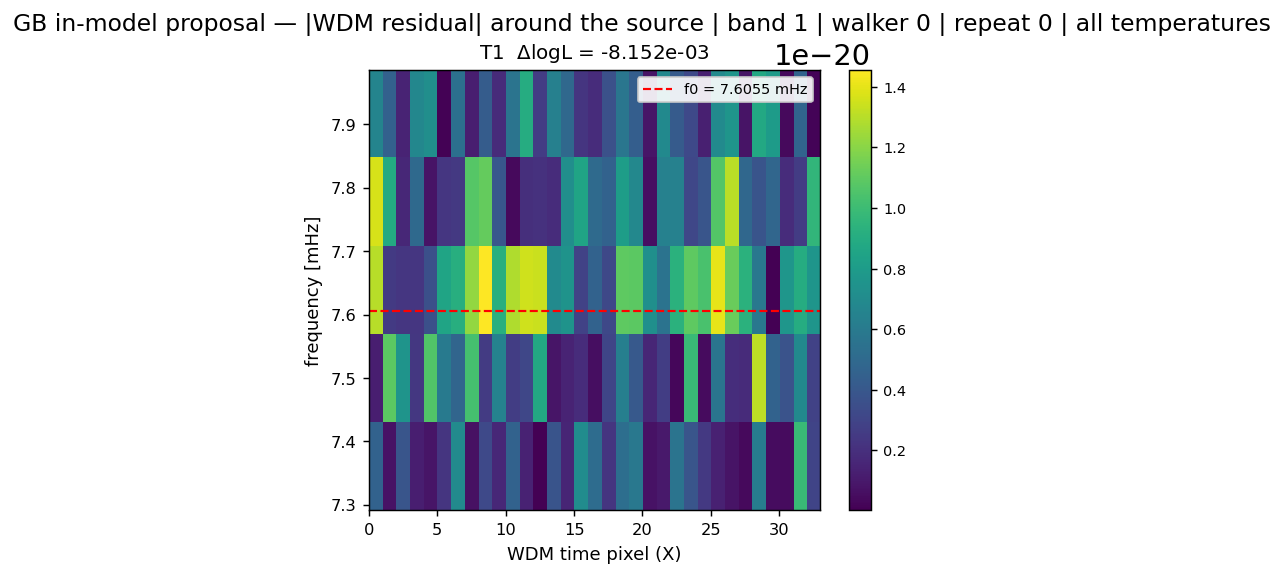

gb_debug/gb_debug_inmodel_band1_w0_move0_0007.png


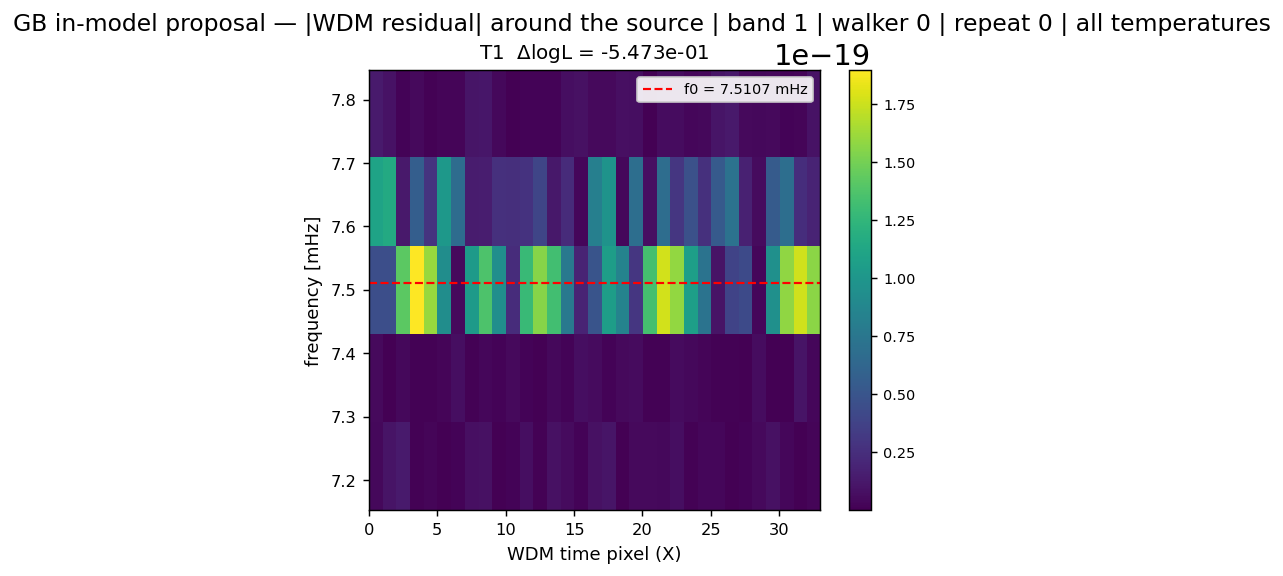

gb_debug/gb_debug_rj_band1_w0_move0_0000.png


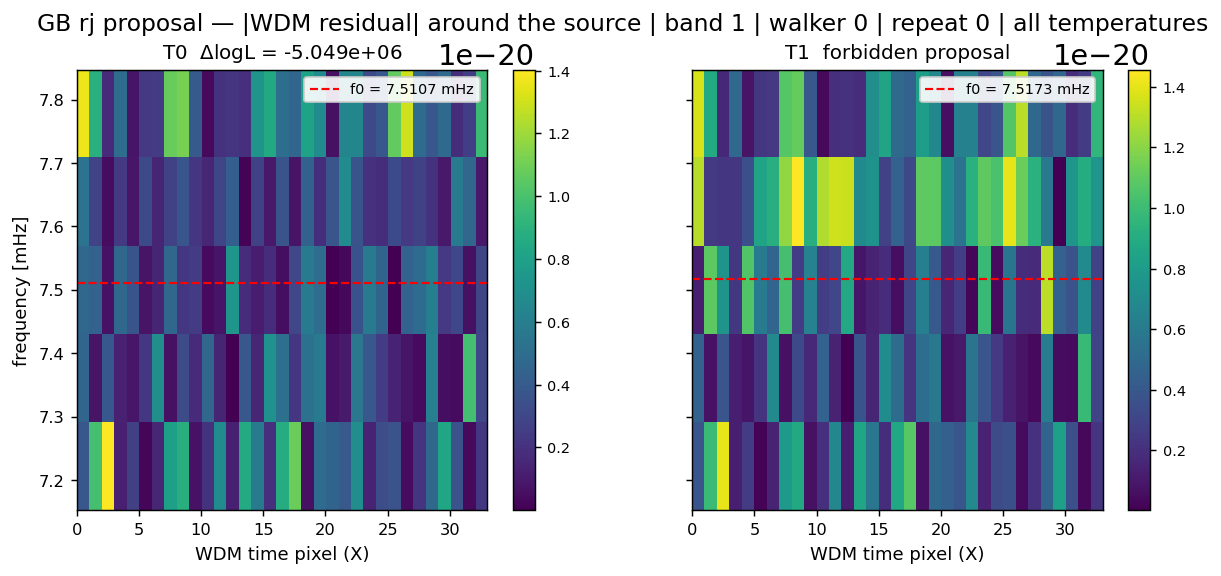

gb_debug/gb_debug_rj_band1_w0_move0_0006.png


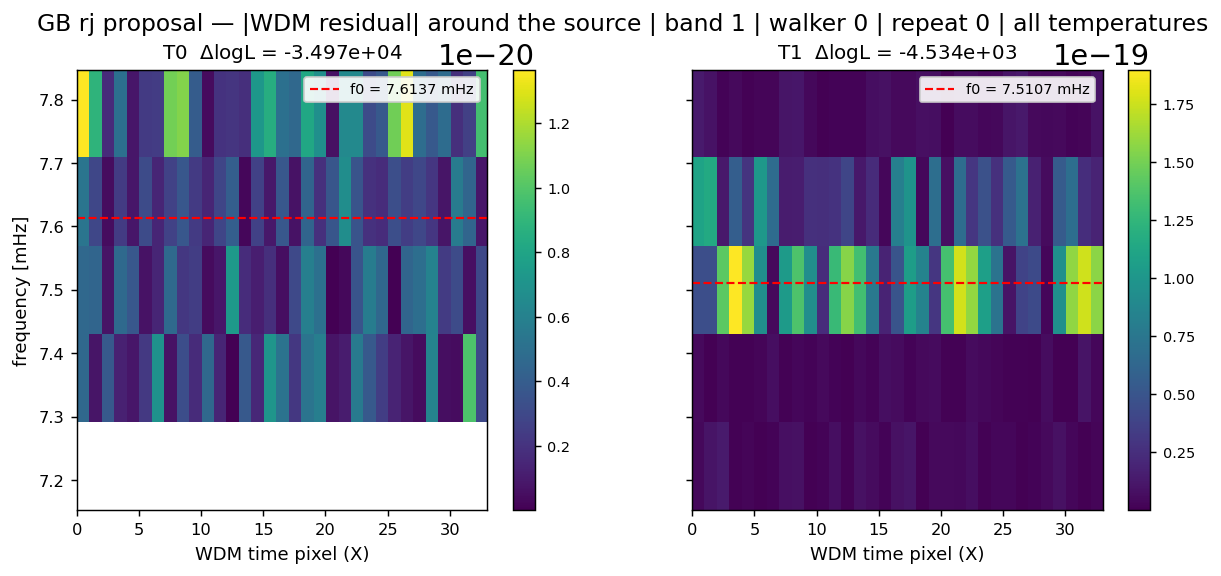

In [17]:
debug_pngs = sorted(glob.glob(OUT + "gb_debug/**/*.png", recursive=True))
print(f"{len(debug_pngs)} debug figures under {OUT}gb_debug/")
for p in debug_pngs:
    print("  ", os.path.relpath(p, OUT))

from IPython.display import Image, display

for p in debug_pngs[:4]:
    print(os.path.relpath(p, OUT))
    display(Image(filename=p, width=900))

## 8. Search mode: zero-leaf start + run trackers

Everything above started the GB leaves **at the catalogue truth** (the
`mode="pe"` default). The realistic zero-knowledge configuration is
**search mode** (`GB_MODE=search` / `fit.gb.mode = "search"`):

- the truth seeding is skipped entirely — the branch starts with **zero
  active leaves** (all `inds` False) and reversible-jump births must find
  the sources;
- the **per-band progressive leaf cap** arms: every band allows at most
  `GB_LEAF_CAP_START` (default 1) leaves per (temp, walker) cell, and each
  band's cap increments independently once it has spent
  `GB_LEAF_CAP_MIN_ITERS` iterations converged at the current cap (within
  `GB_LEAF_CAP_LL_NSIGMA` of the running best band log-likelihood);
- RJ births are **phase-maximised** (two-quadrature analytic maximisation;
  `GB_RJ_PHASE_MAXIMIZE=0` turns that back off).

We launch this one through the **production entry point** —
`scripts/run_global.py --stock gb_no_fg` in a subprocess — for two
reasons. First, it is exactly how a real (MPI) run starts, and running it
twice shows the backend **resuming across processes**. Second, a full
build+run stack holds several GB of memory, and two of them in one
notebook kernel can run the machine out of memory — so we free the PE
run's stack first and let the search run live in its own process.

In [ ]:
# Free the PE run's memory before launching the search subprocess.
fit.reset_build()          # drops the built GeneralSetup / ACS / backend refs
del curr, reader, wdm_data
import gc; gc.collect()
print("PE stack released")

In [ ]:
import subprocess
import sys

SEARCH_OUT = OUT + "search_demo/"

search_env = {
    **os.environ,
    "GB_DEBUG": "1",                  # smoke preset (3-day Tobs, small kernels)
    "GB_MODE": "search",              # zero-leaf start
    "GB_NLEAVES_MAX": "6",            # RJ cost scales with the slot count
    "GB_NUM_REPEAT_PROPOSALS": "2",
    "GF_NUM_ITER": "6",               # iterations per invocation
    "GB_LEAF_CAP_MIN_ITERS": "3",     # default 50; tiny so caps can grow in-demo
    "FILE_STORE_DIR": SEARCH_OUT,
    "BASE_FILE_NAME": "search_demo",
    "GB_DEBUG_DIR": SEARCH_OUT + "gb_debug/",
}


def launch_search_chunk():
    proc = subprocess.run(
        [sys.executable, "../scripts/run_global.py", "--stock", "gb_no_fg"],
        env=search_env, capture_output=True, text=True,
    )
    print("\n".join(proc.stdout.strip().splitlines()[-3:]))
    if proc.returncode != 0:
        print("\n".join(proc.stderr.strip().splitlines()[-15:]))
        raise RuntimeError(f"search chunk failed (exit {proc.returncode})")
    print("chunk complete")


launch_search_chunk()

In [ ]:
from lisatools.globalfit.hdfbackend import GFHDFBackend


def plot_trackers(reader, title=""):
    logl = reader.get_log_like()          # (nsteps, ntemps, nwalkers)
    nleaves = reader.get_inds()["gb"].sum(axis=-1)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax0.plot(logl[:, 0], marker="o")      # cold chain, one line per walker
    ax0.set_xlabel("iteration"); ax0.set_ylabel("log L (cold chain)")
    ax1.plot(nleaves[:, 0], marker="o", drawstyle="steps-post")
    ax1.set_xlabel("iteration"); ax1.set_ylabel("active GB leaves (cold)")
    fig.suptitle(title or f"{logl.shape[0]} stored iterations")
    plt.tight_layout(); plt.show()


search_reader = GFHDFBackend(SEARCH_OUT + "search_demo_testing.h5")
plot_trackers(search_reader, "after the first chunk (zero-leaf start)")

### Running in chunks

`run_global_fit` **resumes from the backend** whenever it already holds
samples, so monitoring a long run is just: run a chunk, read the trackers,
run another chunk — each invocation appends `GF_NUM_ITER` more iterations
to the same backend file (this works identically for `fit.run()` calls
inside one session).

In [ ]:
launch_search_chunk()                 # +6 more iterations, resumed from the backend
search_reader = GFHDFBackend(SEARCH_OUT + "search_demo_testing.h5")
plot_trackers(search_reader, "after the second chunk")
print("iterations stored:", search_reader.iteration)

Watch the two trackers together: logL starts at the data-only value with
zero leaves, then steps up as RJ births land and the per-band caps release
more slots. The search-mode debug figures (band template vs data for the
traced cell) land under this run's own `GB_DEBUG_DIR` —
`search_demo/gb_debug/` — and are the fastest way to check that births are
landing on real signal rather than noise.

## Where to go from here

- **Other stock variants**: `erebor.all_sources` (six branches on Sangria
  data) and `erebor.full_year_combined` (catalogue-driven multi-leaf
  MBH+EMRI+SOBBH; per-branch `use_tdionfly` waveform-path knobs).
- **Whole-object swaps**: `fit.general.domain_settings =
  FDSettings.make_factory(...)`, `fit.general.data_processor_class = ...`,
  `fit.setup_function = my_recipe`, `fit.add_branch("psd", PSDSettings(...))`.
- **New variants**: subclass `EreborFit` in
  `lisatools/globalfit/stock/erebor/variants/` and register it — knobs are
  documented dataclass fields. Per the sprint rule there are **no new
  settings files**; the `global_fit_input/*.py` paths are compatibility
  stubs.